<a href="https://colab.research.google.com/github/rperezen/intro-to-ML/blob/main/HW_2_final_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Environment Detected.
Please upload your 'Housing.csv' file below:


Saving Housing.csv to Housing (3).csv

Successfully loaded Housing (3).csv!

 PROBLEM 1: UNSCALED FEATURES 

--- Problem 1.a (5 Features, Unscaled) ---
Testing LR = 0.1...
   [!] Overflow detected at iteration 22. Gradient exploded due to unscaled features.
Testing LR = 0.05...
   [!] Overflow detected at iteration 23. Gradient exploded due to unscaled features.
Testing LR = 0.01...
   [!] Overflow detected at iteration 26. Gradient exploded due to unscaled features.


/tmp/ipykernel_693/3131363508.py:36: RuntimeWarning: overflow encountered in square
  return (1 / (2 * m)) * np.sum(np.square(predictions - y))


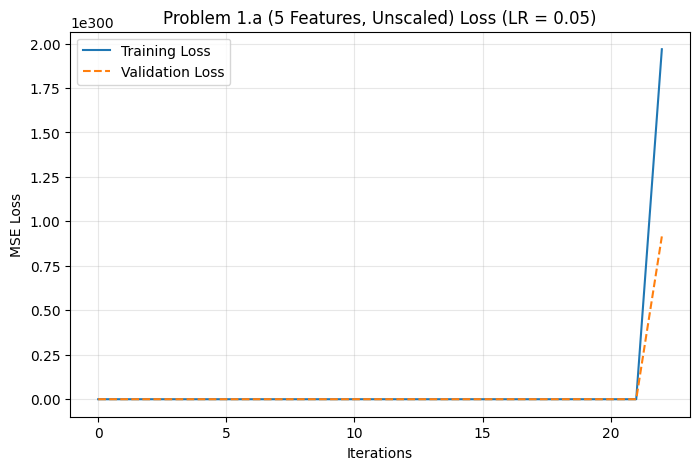


--- Problem 1.b (11 Features, Unscaled) ---
Testing LR = 0.1...
   [!] Overflow detected at iteration 22. Gradient exploded due to unscaled features.
Testing LR = 0.05...


/tmp/ipykernel_693/3131363508.py:36: RuntimeWarning: overflow encountered in square
  return (1 / (2 * m)) * np.sum(np.square(predictions - y))


   [!] Overflow detected at iteration 23. Gradient exploded due to unscaled features.
Testing LR = 0.01...
   [!] Overflow detected at iteration 26. Gradient exploded due to unscaled features.


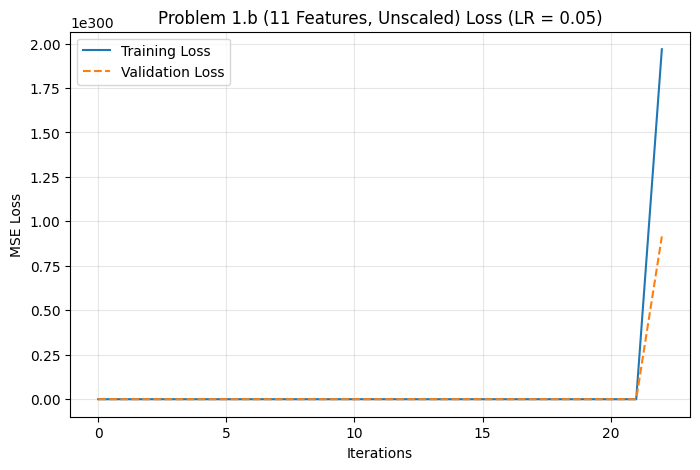


 PROBLEM 2: NORMALIZATION VS STANDARDIZATION 

--- Problem 2.a (5 Features) ---
Normalize Final Validation Loss: 1509780791922.72
Standardize Final Validation Loss: 1066906595232.58


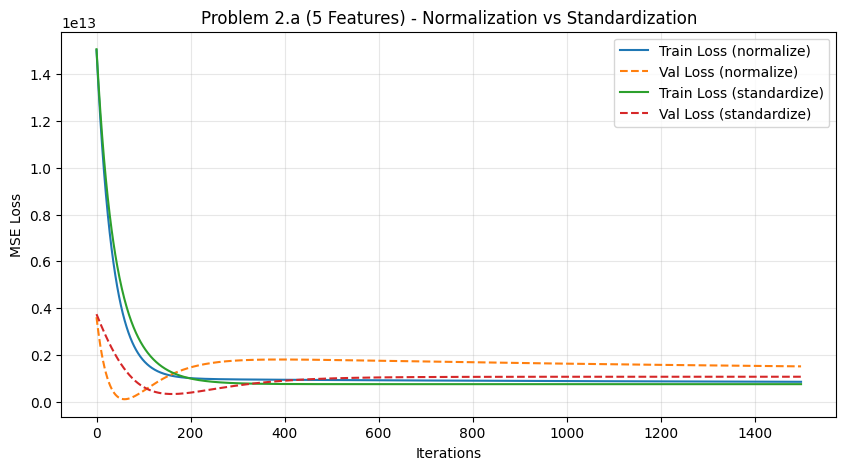


--- Problem 2.b (11 Features) ---
Normalize Final Validation Loss: 750539272354.60
Standardize Final Validation Loss: 578118861874.58


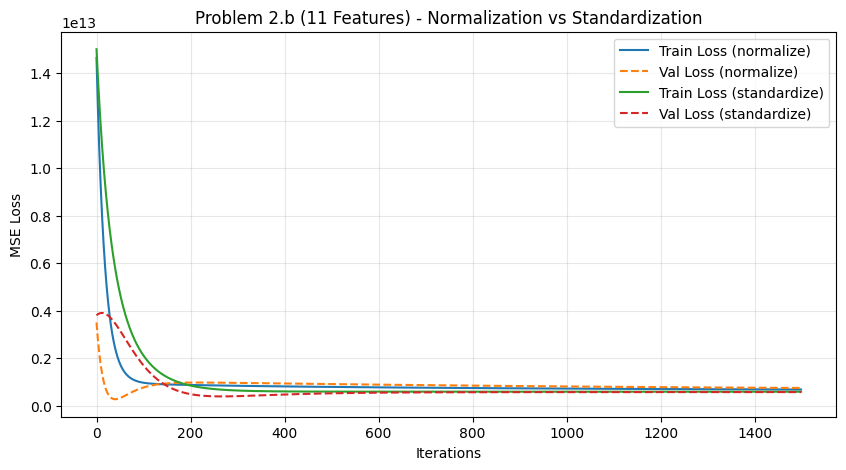


 PROBLEM 3: PARAMETER PENALTY (L2 REGULARIZATION) 

--- Problem 3.a (5 Features) using Standardize ---
Final Validation Loss (Penalty=10): 1084344656268.98


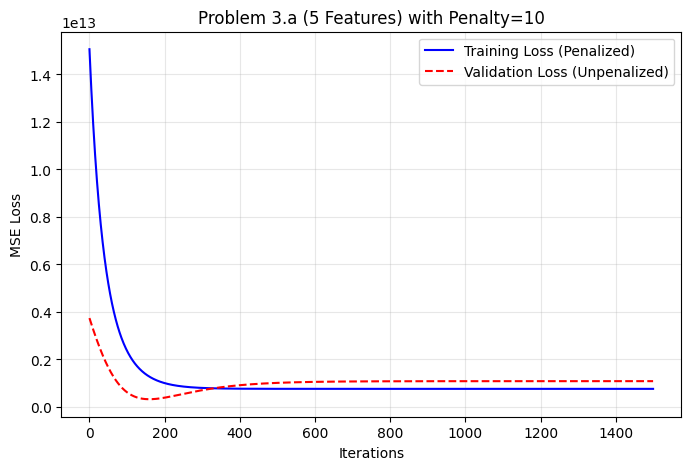


--- Problem 3.b (11 Features) using Standardize ---
Final Validation Loss (Penalty=10): 590341440778.42


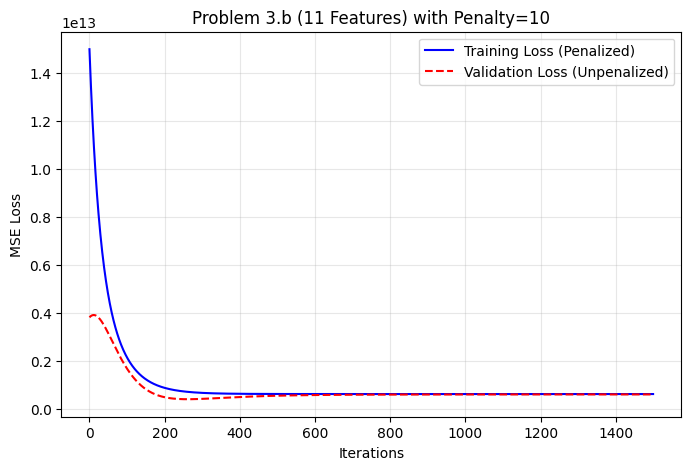

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io

# ==========================================
# 0. SETUP AND DATA LOADING
# ==========================================
try:
    from google.colab import files
    print("Google Colab Environment Detected.")
    print("Please upload your 'Housing.csv' file below:")
    uploaded = files.upload()

    filename = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"\nSuccessfully loaded {filename}!")
except ImportError:
    print("Not running in Google Colab. Make sure 'Housing.csv' is in your local directory.")
    df = pd.read_csv('Housing.csv')

# Map 'yes'/'no' strings to 1 and 0
binary_vars = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for var in binary_vars:
    if var in df.columns:
        df[var] = df[var].apply(lambda x: 1 if str(x).lower() == 'yes' else (0 if str(x).lower() == 'no' else x))


# ==========================================
# CORE ALGORITHM FUNCTIONS
# ==========================================
def compute_loss(X, y, theta):
    """Computes the Mean Squared Error (MSE) loss."""
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum(np.square(predictions - y))

def compute_loss_with_penalty(X, y, theta, penalty):
    """Computes MSE loss plus L2 regularization penalty."""
    m = len(y)
    predictions = X.dot(theta)
    mse_loss = (1 / (2 * m)) * np.sum(np.square(predictions - y))
    # L2 Penalty (excluding the bias term theta[0])
    l2_penalty = (penalty / (2 * m)) * np.sum(np.square(theta[1:]))
    return mse_loss + l2_penalty

def gradient_descent(X_train, y_train, X_val, y_val, learning_rate, iterations, penalty=0):
    """
    Performs gradient descent.
    Handles both unpenalized (Prob 1 & 2) and penalized (Prob 3) logic.
    """
    m_train = len(y_train)
    theta = np.zeros((X_train.shape[1], 1))

    train_losses = []
    val_losses = []

    for i in range(iterations):
        predictions = X_train.dot(theta)
        errors = predictions - y_train

        # Calculate gradients
        gradients = (1 / m_train) * X_train.T.dot(errors)

        # Add penalty to gradients if applicable (exclude bias term theta[0])
        if penalty > 0:
            reg_term = (penalty / m_train) * theta
            reg_term[0] = 0
            gradients += reg_term

        # Update parameters
        theta = theta - learning_rate * gradients

        # Calculate losses
        if penalty > 0:
            t_loss = compute_loss_with_penalty(X_train, y_train, theta, penalty)
        else:
            t_loss = compute_loss(X_train, y_train, theta)

        # Validation loss is ALWAYS unpenalized per assignment instructions
        v_loss = compute_loss(X_val, y_val, theta)

        # Safeguard for exploding gradients (Problem 1 unscaled data issue)
        if np.isinf(t_loss) or np.isnan(t_loss):
            print(f"   [!] Overflow detected at iteration {i}. Gradient exploded due to unscaled features.")
            break

        train_losses.append(t_loss)
        val_losses.append(v_loss)

    return theta, train_losses, val_losses

def prepare_data(df, feature_cols, target_col='price', train_split=0.8, scale_method=None):
    """
    Extracts features, optionally scales them, adds bias, and splits train/val.
    """
    X = df[feature_cols].values
    y = df[target_col].values.reshape(-1, 1)

    if scale_method == 'standardize':
        X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    elif scale_method == 'normalize':
        min_val, max_val = np.min(X, axis=0), np.max(X, axis=0)
        # Avoid division by zero
        X = (X - min_val) / np.where((max_val - min_val) == 0, 1, (max_val - min_val))

    # Add bias column (x_0 = 1)
    X = np.c_[np.ones((X.shape[0], 1)), X]

    split_idx = int(len(X) * train_split)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]

    return X_train, y_train, X_val, y_val


# Global Hyperparameters
iterations = 1500
learning_rates = [0.1, 0.05, 0.01]
features_1a = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
features_1b = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
               'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

# ==========================================
# PROBLEM 1: Unscaled Linear Regression
# ==========================================
print("\n" + "="*50)
print(" PROBLEM 1: UNSCALED FEATURES ")
print("="*50)

def run_problem_1(features, title):
    print(f"\n--- {title} ---")
    X_train, y_train, X_val, y_val = prepare_data(df, features, scale_method=None)

    best_loss = float('inf')
    best_lr = None
    best_train_losses, best_val_losses = [], []

    # Use much smaller learning rates for unscaled features to prevent overflow
    unscaled_learning_rates = [1e-7, 1e-8, 1e-9]

    for lr in unscaled_learning_rates:
        print(f"Testing LR = {lr}...")
        theta, train_loss, val_loss = gradient_descent(X_train, y_train, X_val, y_val, lr, iterations)

        if val_loss and not np.isnan(val_loss[-1]) and val_loss[-1] < best_loss:
            best_loss = val_loss[-1]
            best_lr = lr
            best_train_losses = train_loss
            best_val_losses = val_loss

    if best_lr is None:
        print("All tested learning rates caused exploding gradients because the features (like 'area') are unscaled!")
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(best_train_losses, label='Training Loss')
        plt.plot(best_val_losses, label='Validation Loss', linestyle='--')
        plt.title(f'{title} Loss (LR = {best_lr})')
        plt.xlabel('Iterations')
        plt.ylabel('MSE Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

run_problem_1(features_1a, "Problem 1.a (5 Features, Unscaled)")
run_problem_1(features_1b, "Problem 1.b (11 Features, Unscaled)")


# ==========================================
# PROBLEM 2: Input Normalization vs Standardization
# ==========================================
print("\n" + "="*50)
print(" PROBLEM 2: NORMALIZATION VS STANDARDIZATION ")
print("="*50)

def run_problem_2(features, title):
    print(f"\n--- {title} ---")
    methods = ['normalize', 'standardize']
    results = {}

    # We'll use 0.01 as a stable learning rate for scaled data
    lr = 0.01

    for method in methods:
        X_train, y_train, X_val, y_val = prepare_data(df, features, scale_method=method)
        theta, train_losses, val_losses = gradient_descent(X_train, y_train, X_val, y_val, lr, iterations)

        results[method] = {'train': train_losses, 'val': val_losses}
        print(f"{method.capitalize()} Final Validation Loss: {val_losses[-1]:.2f}")

    plt.figure(figsize=(10, 5))
    for method in methods:
        plt.plot(results[method]['train'], label=f'Train Loss ({method})')
        plt.plot(results[method]['val'], label=f'Val Loss ({method})', linestyle='--')

    plt.title(f'{title} - Normalization vs Standardization')
    plt.xlabel('Iterations')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    return results

res_2a = run_problem_2(features_1a, "Problem 2.a (5 Features)")
res_2b = run_problem_2(features_1b, "Problem 2.b (11 Features)")


# ==========================================
# PROBLEM 3: Adding Parameter Penalty (L2 / Ridge)
# ==========================================
print("\n" + "="*50)
print(" PROBLEM 3: PARAMETER PENALTY (L2 REGULARIZATION) ")
print("="*50)

def run_problem_3(features, title, best_scaling_method='standardize', penalty=10):
    print(f"\n--- {title} using {best_scaling_method.capitalize()} ---")

    X_train, y_train, X_val, y_val = prepare_data(df, features, scale_method=best_scaling_method)
    lr = 0.01

    theta, train_losses, val_losses = gradient_descent(
        X_train, y_train, X_val, y_val, lr, iterations, penalty=penalty
    )

    print(f"Final Validation Loss (Penalty={penalty}): {val_losses[-1]:.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Loss (Penalized)', color='blue')
    plt.plot(val_losses, label='Validation Loss (Unpenalized)', color='red', linestyle='--')
    plt.title(f'{title} with Penalty={penalty}')
    plt.xlabel('Iterations')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Typically, standardization performs best, so we use it for Problem 3
run_problem_3(features_1a, "Problem 3.a (5 Features)", best_scaling_method='standardize', penalty=10)
run_problem_3(features_1b, "Problem 3.b (11 Features)", best_scaling_method='standardize', penalty=10)
